In [1]:
import tifffile
from fresnel import propagate
import matplotlib.pyplot as plt

0.44461963 -5.4890833
1.0 0.0
2.4317026 0.1981046


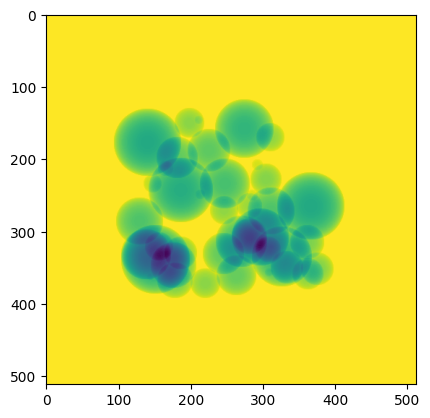

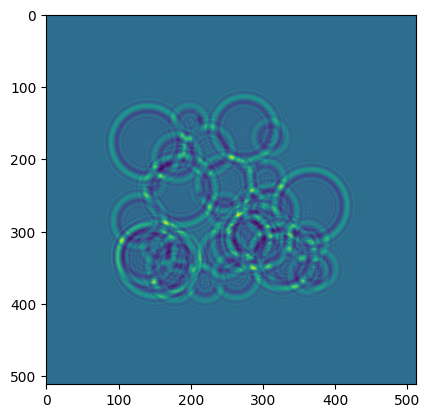

In [9]:
energy = 15
z = 0.01
pv = 1e-7
img_f = tifffile.imread('../examples/test_data/phase_sphere.tiff')
print(img_f.max(), img_f.min())
img_a =1-(img_f-img_f.min()) / (img_f.max() - img_f.min())
print(img_a.max(), img_a.min())
ifp = propagate(img_f, img_a, energy, z, pv, 0.001)
print(ifp.max(), ifp.min())
plt.imshow(img_f)
plt.show()
plt.imshow(ifp)
plt.show()
tifffile.imwrite('../examples/test_data/hologram_sphere_e15k_z10mm_p100nm_abs001.tiff', ifp)

Found result files: ['../examples/test_results/sphere_phase_e15k_z100mm_p100nm_abs001.tiff', '../examples/test_results/sphere_phase_e15k_z10mm_p100nm_abs001.tiff', '../examples/test_results/sphere_phase_e15k_z1mm_p100nm_abs001.tiff', '../examples/test_results/sphere_phase_e15k_z50mm_p100nm_abs001.tiff', '../examples/test_results/sphere_phase_e15k_z5mm_p100nm_abs001.tiff']


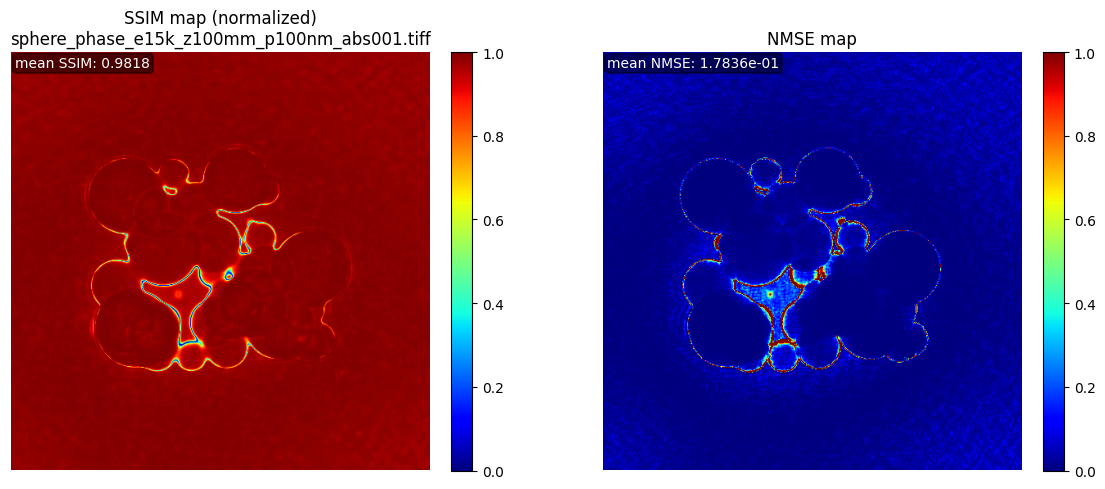

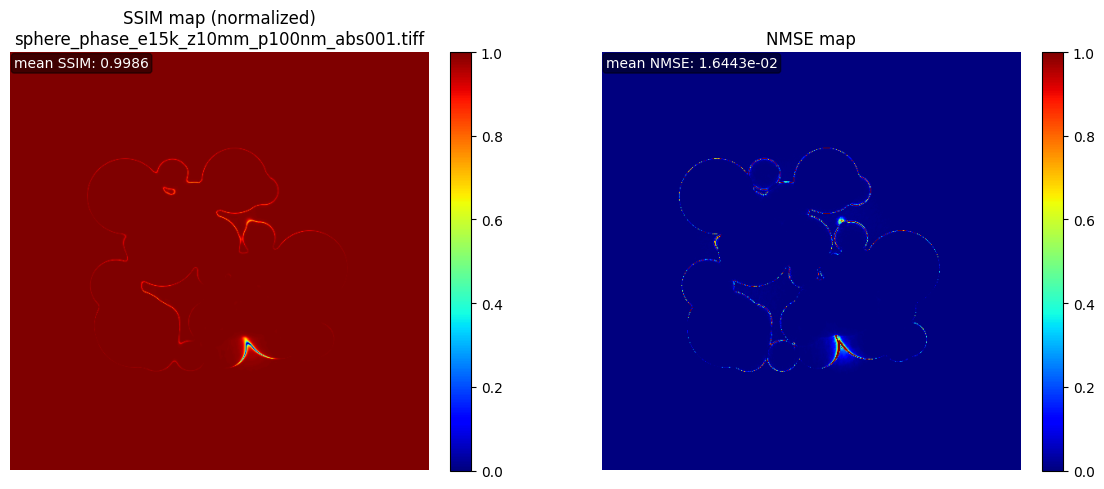

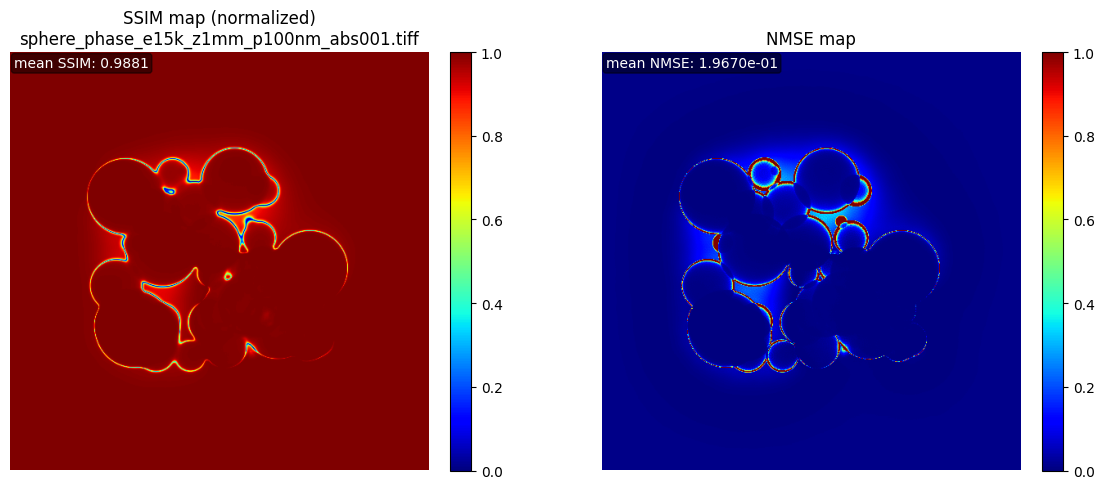

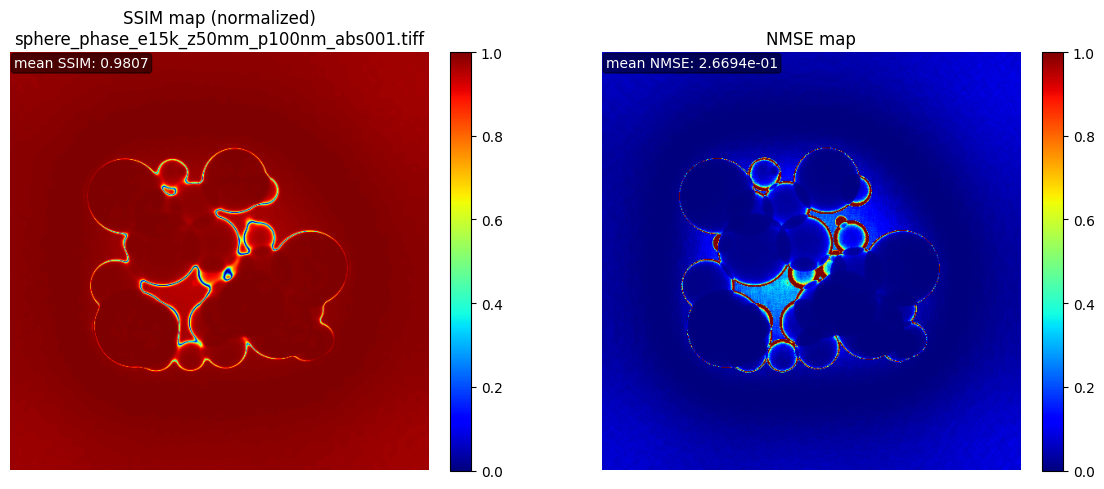

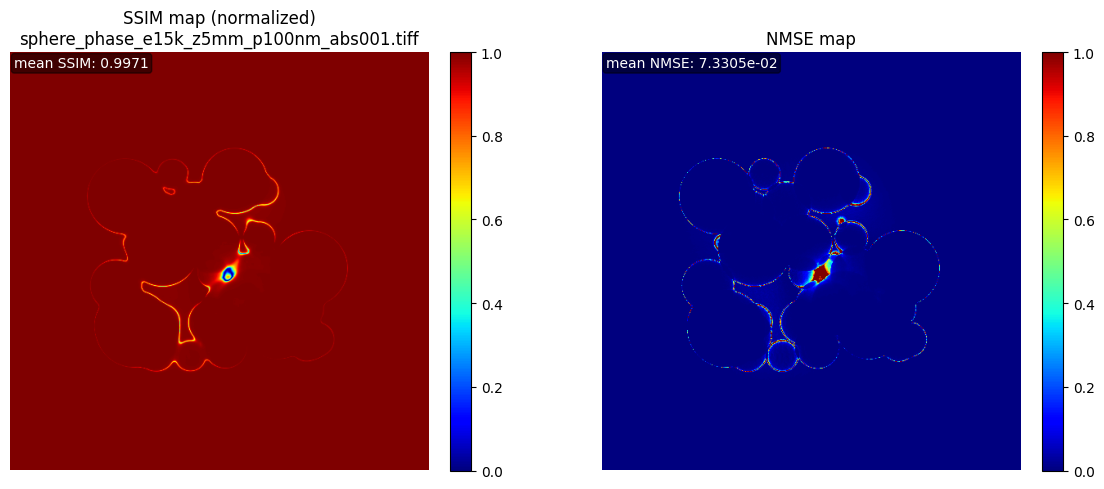

In [16]:
import glob
import numpy as np
from skimage.metrics import structural_similarity as ssim

# Find all sphere_phase* files in test_results
result_files = sorted(glob.glob('../examples/test_results/sphere_phase*.tiff'))
print('Found result files:', result_files)

ssim_maps = []
nmse_maps = []
ssim_means = []
nmse_means = []

for f in result_files:
    img_r = tifffile.imread(f)
    # Ensure shapes match
    if img_r.shape != img_f.shape:
        print(f'Shape mismatch for {f}, skipping.')
        continue
    # Compute SSIM map
    ssim_val, ssim_map = ssim(img_f, img_r, data_range=img_f.max()-img_f.min(), full=True)
    # Normalize SSIM map to [0, 1]
    ssim_map_norm = (ssim_map - ssim_map.min()) / (ssim_map.max() - ssim_map.min() + 1e-8)
    ssim_maps.append(ssim_map_norm)
    ssim_means.append(np.mean(ssim_map_norm))
    # Compute NMSE map
    nmse_map = (img_f - img_r) ** 2 / (np.abs(img_f) + 1e-8) ** 2
    nmse_maps.append(nmse_map)
    nmse_means.append(np.mean(nmse_map))

# Plot SSIM and NMSE maps for each result
for i, f in enumerate(result_files):
    if i >= len(ssim_maps):
        continue
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    im0 = axs[0].imshow(ssim_maps[i], cmap='jet', vmin=0, vmax=1)
    axs[0].set_title(f'SSIM map (normalized)\n{f.split("/")[-1]}')
    axs[0].axis('off')
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    # Add mean SSIM value at bottom left
    axs[0].text(0.01, 0.99, f"mean SSIM: {ssim_means[i]:.4f}", color='white', fontsize=10, ha='left', va='top', transform=axs[0].transAxes, bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))
    im1 = axs[1].imshow(nmse_maps[i], cmap='jet', vmin=0, vmax=1)
    axs[1].set_title('NMSE map')
    axs[1].axis('off')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    # Add mean NMSE value at bottom left
    axs[1].text(0.01, 0.99, f"mean NMSE: {nmse_means[i]:.4e}", color='white', fontsize=10, ha='left', va='top', transform=axs[1].transAxes, bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))
    plt.tight_layout()
    plt.show()